<a href="https://colab.research.google.com/github/Kiruthika1802/Spatio-Temporal-Intelligence-for-Real-Time-Vehicle-Detection/blob/main/new_final_copy_of_Spatio_Temporal_Intelligence_for_Real_Time_Vehicle_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(1) Environment Setup : Installing the Ultralytics library to enable YOLOv8

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.2 MB/s eta 0:00:00


(2) Module 1 - Spatial Detection & Tracking: Running the YOLOv8 object detector with BoT-SORT tracking to identify vehicles and extract their movement paths (trajectories) from the video

In [2]:
from ultralytics import YOLO
from collections import defaultdict
import cv2
import numpy as np
from IPython.display import FileLink

# Load the model
model = YOLO('yolov8n.pt')

# --- IMPORTANT: Set your video's filename here ---
video_filename = '/content/sample video 1.mp4' # Make sure this matches your upload
output_filename = 'output_video.mp4'

# A dictionary to store the trajectory of each tracked object
trajectories = defaultdict(list)

# Get video properties for saving the output
cap = cv2.VideoCapture(video_filename)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
cap.release()

# Define the video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_filename, fourcc, fps, (width, height))

print(f"Processing '{video_filename}'...")

# Use the tracker on the video
results = model.track(
    source=video_filename,
    stream=True,
    classes=[2, 3, 5, 7], # car, motorbike, bus, truck
    conf=0.7,
    tracker="botsort.yaml"
)

# Loop through the results frame by frame
for r in results:
    # 1. Write the annotated frame to the output video
    annotated_frame = r.plot()
    out.write(annotated_frame)

    # 2. Extract trajectories
    boxes = r.boxes
    if boxes.id is not None:
        for i in range(len(boxes.id)):
            track_id = int(boxes.id[i])
            bbox_normalized = boxes.xyxyn[i].cpu().numpy()
            trajectories[track_id].append(bbox_normalized)

# Release the video writer
out.release()

print("\n✅ Trajectory extraction complete!")
print(f"✅ Output video saved as '{output_filename}'")

# Display download link
display(FileLink(output_filename))

# Let's see what we've captured
num_vehicles = len(trajectories)
print(f"Number of unique vehicles tracked: {num_vehicles}")

# Find the longest trajectory to use for training
longest_trajectory_id = -1
max_length = -1
for track_id, path in trajectories.items():
    if len(path) > max_length:
        max_length = len(path)
        longest_trajectory_id = track_id

if longest_trajectory_id != -1:
    print(f"The longest trajectory belongs to vehicle ID '{longest_trajectory_id}' with {max_length} frames.")
else:
    print("No vehicles were tracked.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Processing '/content/sample video 1.mp4'...
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 2 packages in 478ms
Prepared 1 package in 123ms
Installed 1 package in 1ms
 + lap==0.5.12

requirements: AutoUpdate success ✅ 1.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


video 1/1 (frame 1/1501) /content/sample video 1.mp4: 384x640 5 cars, 1 bus, 68.0ms
video 1/1 (frame 2/1501) /content/sample video 1.mp4: 384x640 4 cars, 1 bus, 7.2ms
video 1/1 (frame 3/1501) /content/sample video 1.mp4: 384x640 5 cars, 1 bus, 8.8ms
video 1/1 (frame 4/1501) /content/sa

/content/output_video.mp4

Number of unique vehicles tracked: 47
The longest trajectory belongs to vehicle ID '33' with 275 frames.


(3) Module 2 - Data Preparation: Processing the extracted trajectory data into sequences (past 10 frames) to prepare it for training the LSTM model

In [3]:
import numpy as np

# Let's use the longest trajectory for training our LSTM
if longest_trajectory_id != -1:
    # Get the list of bounding boxes for the longest path
    trajectory = trajectories[longest_trajectory_id]

    # --- Hyperparameter: Define the "memory" of the LSTM ---
    sequence_length = 10

    # These lists will hold our training data
    X_train_lstm = []
    y_train_lstm = []

    print(f"Creating training sequences from a trajectory of length {len(trajectory)}...")

    # Slide the window across the trajectory
    for i in range(len(trajectory) - sequence_length):
        input_sequence = trajectory[i : i + sequence_length]
        target_bbox = trajectory[i + sequence_length]

        X_train_lstm.append(input_sequence)
        y_train_lstm.append(target_bbox)

    # Convert the lists to NumPy arrays for training
    X_train_lstm = np.array(X_train_lstm)
    y_train_lstm = np.array(y_train_lstm)

    # --- FIX: The np.squeeze line has been removed ---

    print("\n✅ Data preparation for LSTM complete!")
    print(f"Shape of input data (X): {X_train_lstm.shape}")
    print(f"   (Samples, Sequence Length, Features)")
    print(f"Shape of target data (y): {y_train_lstm.shape}")
    print(f"   (Samples, Features)")

else:
    print("Cannot prepare data as no trajectories were found.")

Creating training sequences from a trajectory of length 275...

✅ Data preparation for LSTM complete!
Shape of input data (X): (265, 10, 4)
   (Samples, Sequence Length, Features)
Shape of target data (y): (265, 4)
   (Samples, Features)


(4) Module 3 - Temporal Model Training: Building and training the LSTM neural network to learn motion patterns from the prepared data, and plotting the training loss to show improvement

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,204 (43.77 KB)

 Trainable params: 11,204 (43.77 KB)

 Non-trainable params: 0 (0.00 B)


Starting LSTM model training...
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.2166 - val_loss: 0.3363
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0557 - val_loss: 0.0382
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0055 - val_loss: 0.0108
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0088 - val_loss: 0.0191
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0025 - val_loss: 0.0354
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0024 - val_loss: 0.0220
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013 - val_loss: 0.0118
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0011 - val_loss: 0.0136
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.6167e-04 - val_loss: 0.0139
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 8.4268e-04 - val_loss: 0.0108
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.3581e-04 - val_loss: 0.0110
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s

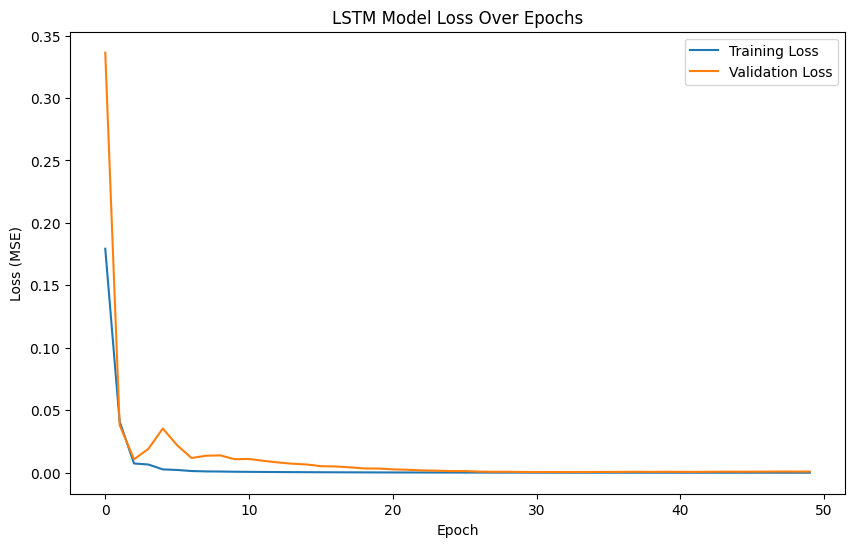

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# 1. Build the LSTM Model Architecture
lstm_model = Sequential()
# Add an LSTM layer. input_shape is (sequence_length, num_features)
# We have 10 frames in the sequence and 4 features (the bbox coordinates).
lstm_model.add(LSTM(units=50, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
# Add a Dense output layer with 4 neurons to predict the 4 bbox coordinates
lstm_model.add(Dense(4))

# 2. Compile the Model
# For a regression task like predicting coordinates, 'mean_squared_error' is the best loss function.
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# Print the model's architecture
lstm_model.summary()

# 3. Train the Model
print("\nStarting LSTM model training...")
history_lstm = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=50, # Training for more epochs as LSTMs can take longer to learn
    batch_size=32,
    validation_split=0.1, # Use 10% of data to check for overfitting
    verbose=1
)

print("\n✅ LSTM Training Complete!")

# 4. Plot the Training and Validation Loss
plt.figure(figsize=(10, 6))
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

(5) Result Visualization: Testing the trained model by predicting a vehicle's next position and visualizing the result (Cyan Box) against the actual position (Green Box)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


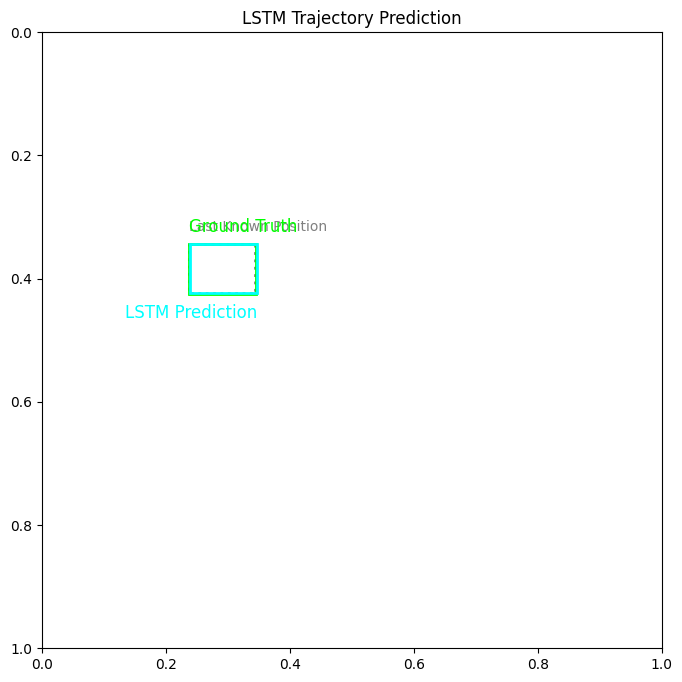

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Let's take a sample from the data we prepared
# You can change the sample_index to see different predictions
sample_index = 50
input_sequence = X_train_lstm[sample_index]
ground_truth_next_box = y_train_lstm[sample_index]

# The model expects a "batch" of inputs, so we add an extra dimension
input_for_prediction = np.expand_dims(input_sequence, axis=0)

# Use the LSTM model to predict the next bounding box
predicted_next_box = lstm_model.predict(input_for_prediction)[0]

# --- Visualize the results ---
# We'll draw on a blank canvas for clarity
fig, ax = plt.subplots(1, figsize=(8, 8))
ax.set_xlim(0, 1)
ax.set_ylim(1, 0) # Invert Y axis to match image coordinates (0,0 is top-left)
ax.set_title("LSTM Trajectory Prediction")

# Draw the last known position of the vehicle (the 10th box in the input sequence)
last_known_box = input_sequence[-1]
y_min, x_min, y_max, x_max = last_known_box
rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, linewidth=2, edgecolor='gray', facecolor='none', linestyle=':')
ax.add_patch(rect)
plt.text(x_min, y_min - 0.02, 'Last Known Position', color='gray', fontsize=10)

# Draw the Ground Truth box (the REAL next position) in GREEN
y_min, x_min, y_max, x_max = ground_truth_next_box
rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, linewidth=2, edgecolor='lime', facecolor='none')
ax.add_patch(rect)
plt.text(x_min, y_min - 0.02, 'Ground Truth', color='lime', fontsize=12)

# Draw the PREDICTED box in CYAN
y_min, x_min, y_max, x_max = predicted_next_box
rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, linewidth=2, edgecolor='cyan', facecolor='none')
ax.add_patch(rect)
plt.text(x_max, y_max + 0.04, 'LSTM Prediction', color='cyan', fontsize=12, ha='right')

plt.show()